### Step 1 : Load Libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [82]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

### Step 2: Data Overview and Exploration

In [83]:
df = pd.read_csv(r"C:\Users\cashk\OneDrive\Desktop\Projects\Customer Churn ML\Churn_predictor_ML\data\telco_comm_churn.csv")
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Basic Information

In [84]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [85]:
print(df.shape)

(7043, 21)


In [ ]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [87]:
print("Target Variable Distribution:\n", df['Churn'].value_counts(normalize=True)*100)

Target Variable Distribution:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Analyze Numerical Features

In [88]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [89]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [90]:
df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Visualize Target Variable

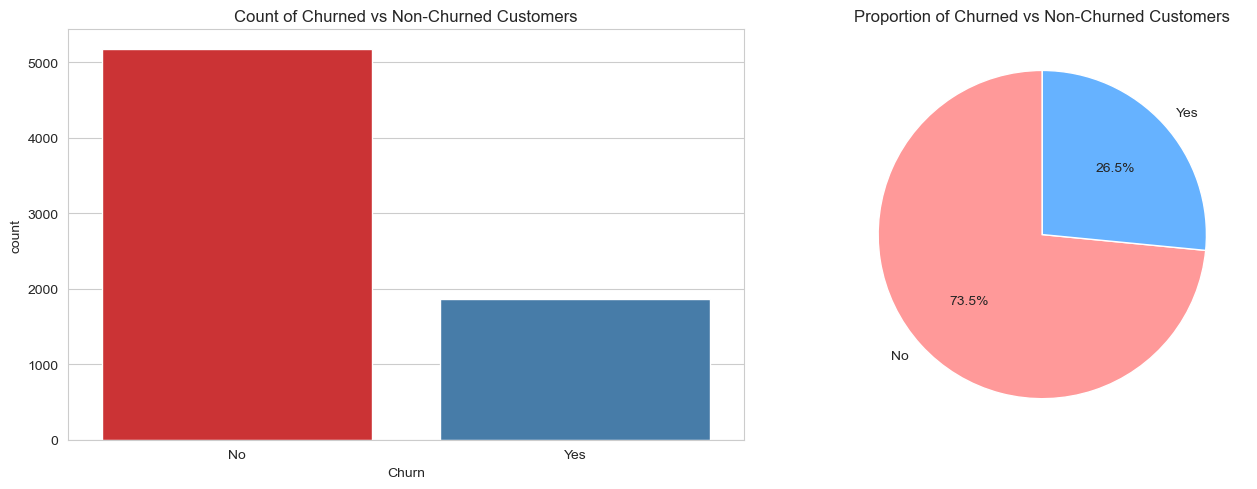

In [91]:
fig,ax = plt.subplots(1,2, figsize=(14,5))
sns.countplot(x='Churn', data = df, ax=ax[0],palette='Set1')

ax[0].set_title('Count of Churned vs Non-Churned Customers')
ax[1].set_title('Proportion of Churned vs Non-Churned Customers')

Churn = df['Churn'].value_counts()
ax[1].pie(Churn, labels=Churn.index, autopct='%1.1f%%', startangle=90, colors=['#FF9999','#66B2FF'])
plt.tight_layout()
plt.savefig(r"C:\Users\cashk\OneDrive\Desktop\Projects\Customer Churn ML\Churn_predictor_ML\reports\churn_distribution.png")
plt.show()


### Numerical Features VS Churn

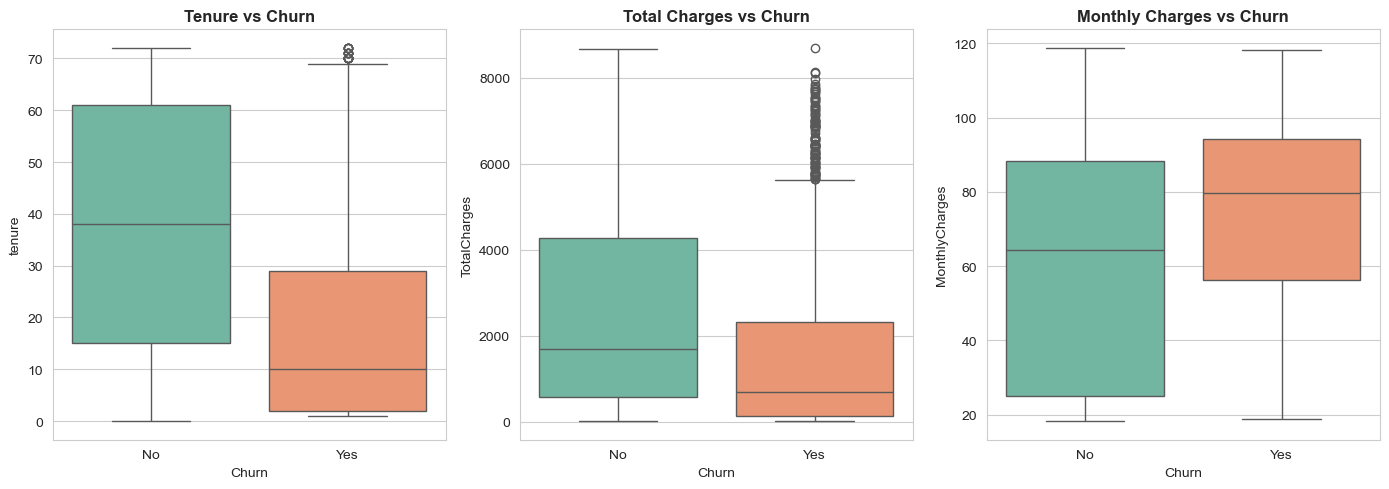

In [109]:
fig,ax = plt.subplots(1,3, figsize=(14,5))

#first boxplot for tenure vs churn
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2',ax = ax[0])
ax[0].set_title('Tenure vs Churn',fontweight='bold')


#second boxplot for TotalCharges vs churn
sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='Set2',ax = ax[1])
ax[1].set_title('Total Charges vs Churn',fontweight='bold')


#third boxplot for MonthlyCharges vs churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2',ax = ax[2])
ax[2].set_title('Monthly Charges vs Churn',fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\cashk\OneDrive\Desktop\Projects\Customer Churn ML\Churn_predictor_ML\reports\numerical_features_vs_churn.png")
plt.show()

### Analyze Categorical Features

In [92]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [93]:
categorical_cols.remove("customerID")
categorical_cols.remove("Churn")
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [94]:
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

Categorical Columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


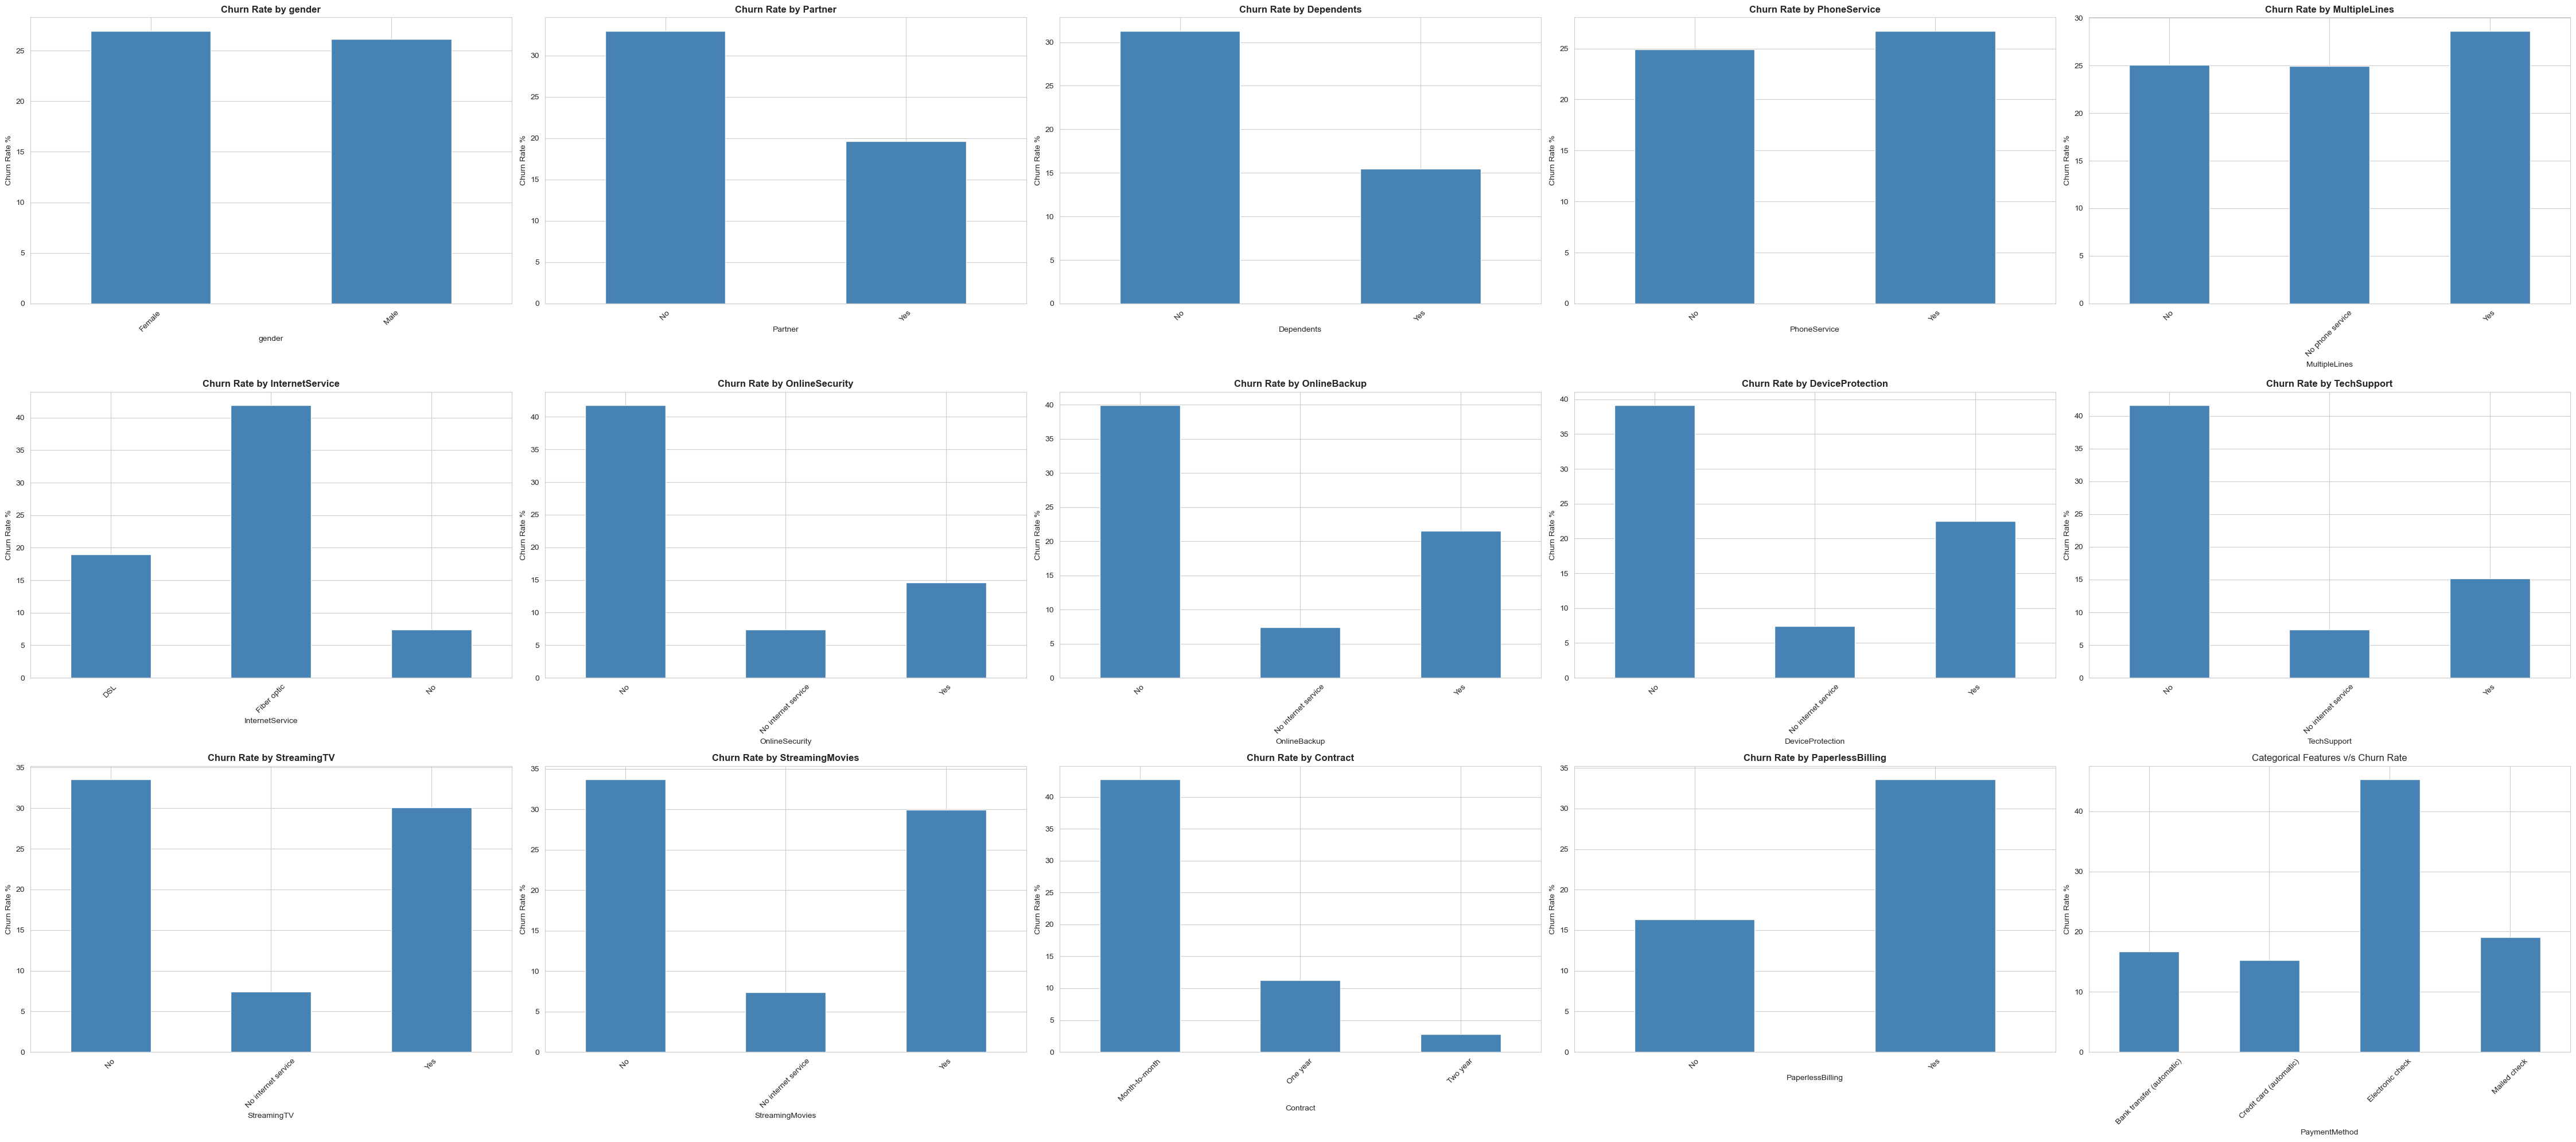

In [ ]:
fig,ax = plt.subplots(3,5, figsize=(45,20))
ax=ax.flatten()

for idx, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').sum()/len(x)*100)
    churn_rate.plot(kind='bar',ax = ax[idx], color= "steelblue")
    ax[idx].set_title(f'Churn Rate by {col}', fontweight='bold')
    ax[idx].set_ylabel('Churn Rate %')
    ax[idx].set_xlabel(col)
    ax[idx].tick_params(axis='x', rotation=45)
    
    
plt.title('Categorical Features v/s Churn Rate')
plt.tight_layout()
plt.savefig(r"C:\Users\cashk\OneDrive\Desktop\Projects\Customer Churn ML\Churn_predictor_ML\reports\categorical_features_vs_churn.png")
plt.show()


In [110]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes':1, 'No':0})

In [112]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges','Churn']
correlation_matrix = df_corr[numerical_features].corr()
correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


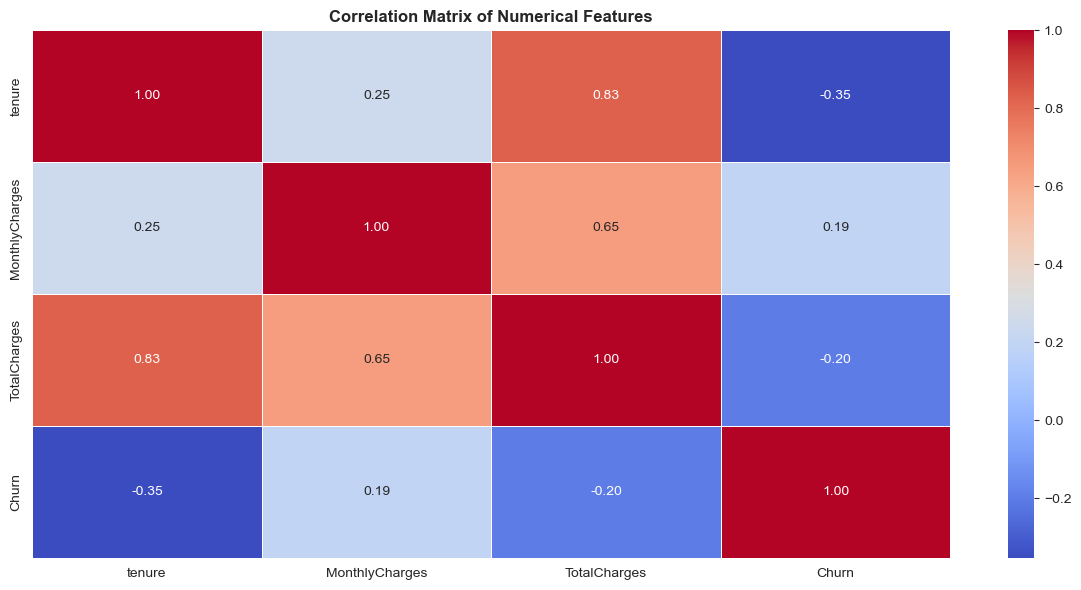

In [114]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\cashk\OneDrive\Desktop\Projects\Customer Churn ML\Churn_predictor_ML\reports\correlation_matrix.png")
plt.show()




NOTE: A multicolinearity between 'tenure' and 'TotalCharges'

In [115]:
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print(f"\n1. Dataset size: {df.shape[0]} customers, {df.shape[1]} features")
print(f"2. Churn rate: {(df['Churn']=='Yes').sum()/len(df)*100:.2f}%")
print(f"3. Missing Values: {df.isnull().sum().sum()} total")

avg_tenure_churn = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_no_churn = df[df['Churn'] == 'No']['tenure'].mean()

print(f"4. Average Tenure (Churned): {avg_tenure_churn:.1f} months")
print(f"5. Average Tenure (Not Churned): {avg_tenure_no_churn:.1f} months")

avg_monthly_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_no_churn = df[df['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"6. Average Monthly Chrages (Churned): ${avg_monthly_churn:.1f}")
print(f"7. Average Monthly (Not Churned): ${avg_monthly_no_churn:.1f}\n")

print("="*60)
print('A holistic analysis reveals that short-term, high-cost digital\n services (Fiber Optic/Electronic Checks) are the primary churn\n drivers, while long-term tenure and value-added security\n services are the strongest indicators of customer loyalty.')
print("="*60)

print("="*60)
print("EDA COMPLETED")
print("="*60)

KEY INSIGHTS FROM EDA

1. Dataset size: 7043 customers, 21 features
2. Churn rate: 26.54%
3. Missing Values: 11 total
4. Average Tenure (Churned): 18.0 months
5. Average Tenure (Not Churned): 37.6 months
6. Average Monthly Chrages (Churned): $74.4
7. Average Monthly (Not Churned): $61.3

A holistic analysis reveals that short-term, high-cost digital
 services (Fiber Optic/Electronic Checks) are the primary churn
 drivers, while long-term tenure and value-added security
 services are the strongest indicators of customer loyalty.
EDA COMPLETED
